In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [26]:
# Define results directory
results_dir = '/Users/arpitkapoor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/Shared/Projects/10_Katana/04_groundwater/results/gino_predictions_20260117_131908'

# Load prediction and target files
val_preds = np.load(os.path.join(results_dir, 'val_predictions.npy'))
val_targets = np.load(os.path.join(results_dir, 'val_targets.npy'))

# Load coordinate files (assuming same as training coords)
coords = pickle.load(open(os.path.join(results_dir, 'train_coords.pkl'), 'rb'))[0]

print(f"Predictions shape: {val_preds.shape}")
print(f"Targets shape: {val_targets.shape}")
print(f"Coordinates shape: {coords.shape}")

Predictions shape: (568, 10227, 1, 2)
Targets shape: (568, 10227, 1, 2)
Coordinates shape: (10227, 3)


In [27]:
# Apply inverse coordinate transformation
coord_mean = np.array([357225.66528974305, 6457743.243307921, -9.277822477621577])
coord_std = np.array([569.1699998979727, 566.3579737855055, 15.2656561762675])
coords = coords * coord_std + coord_mean
print(f"Unnormalized Coordinates range: \n X: [{coords[:, 0].min()}, {coords[:, 0].max()}] \n Y: [{coords[:, 1].min()}, {coords[:, 1].max()}] \n Z: [{coords[:, 2].min()}, {coords[:, 2].max()}]")

Unnormalized Coordinates range: 
 X: [355702.3992551436, 358345.95058245375] 
 Y: [6456013.4359585, 6459170.983097088] 
 Z: [-34.999999128925666, 33.86512346570334]


In [28]:
# Reshape predictions and targets to (N_nodes, T, N_vars)
# Original shape likely (N_samples, N_nodes, T_out, N_vars) or similar
if len(val_preds.shape) == 4:
    preds = np.squeeze(val_preds, axis=2).transpose(1, 0, 2)
    targets = np.squeeze(val_targets, axis=2).transpose(1, 0, 2)
else:
    # Fallback if shape is already (N_nodes, T, N_vars)
    preds = val_preds
    targets = val_targets

mass_conc_preds = preds[..., 0]
mass_conc_targets = targets[..., 0]

print(f"Reshaped Mass Conc Targets shape: {mass_conc_targets.shape}")

Reshaped Mass Conc Targets shape: (10227, 568)


In [29]:
def compute_constrained_mse(obs, pred, verbose=False):
    """
    Compute MSE for each node, excluding time steps where observation is negative.
    """
    n_nodes = obs.shape[0]
    mses = np.full(n_nodes, np.nan, dtype=float)

    for i in range(n_nodes):
        mask = obs[i] >= 0
        if verbose:
            print(f"Node {i}: {np.sum(mask)} valid time steps out of {obs.shape[1]}")
        if np.any(mask):
            mses[i] = np.mean((obs[i, mask] - pred[i, mask]) ** 2)

    return mses


def compute_final_step_mse(obs, pred):
    """
    Compute per-node squared error at the final time step only.
    Nodes with negative final-step observation are set to NaN.
    """
    obs_last = obs[:, -1]
    pred_last = pred[:, -1]

    mses = np.full(obs.shape[0], np.nan, dtype=float)
    valid = obs_last >= 0
    mses[valid] = (obs_last[valid] - pred_last[valid]) ** 2
    return mses

node_mse = compute_constrained_mse(mass_conc_targets, mass_conc_preds)

final_mse = compute_final_step_mse(mass_conc_targets, mass_conc_preds)

In [30]:
final_mse

array([ 98792.27574964, 298099.73984429,  89763.43698827, ...,
         3895.22389733,  32744.7777716 ,  25581.22559554], shape=(10227,))

In [31]:
node_mse

array([2.02315081e+05, 1.12105889e+05, 5.19180790e+07, ...,
       1.16707718e+04, 1.95271946e+04, 1.30138781e+04], shape=(10227,))

In [32]:
# Get unique Z levels
unique_z = np.sort(np.unique(coords[:, 2]))
print(f"Found {len(unique_z)} unique Z levels.")

Found 2771 unique Z levels.


,bin,mean_z,bin_width,count
0,"[-35.0000, -34.3113)",-34.655674,0.688651,787
1,"[-28.1135, -27.4248)",-27.769161,0.688651,787
2,"[-22.6043, -21.9156)",-22.259951,0.688651,786
3,"[-18.4724, -17.7837)",-18.128044,0.688651,783
4,"[-14.3405, -13.6518)",-13.996137,0.688651,785
5,"[-10.2086, -9.5199)",-9.864229,0.688651,765
6,"[-6.0766, -5.3880)",-5.732322,0.688651,681
7,"[-2.6334, -1.9447)",-2.289066,0.688651,688
8,"[1.4985, 2.1872)",1.842841,0.688651,542
9,"[6.3191, 7.0077)",6.663400,0.688651,485


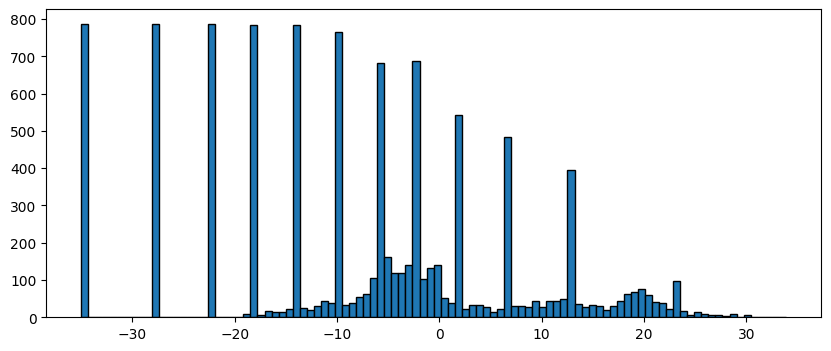

In [33]:
plt.figure(figsize=(10, 4))
counts, bin_edges, _ = plt.hist(coords[:, 2], bins=100, edgecolor='k')

bin_count_dict = {
    f"[{bin_edges[i]:.4f}, {bin_edges[i+1]:.4f})": int(counts[i])
    for i in range(len(counts))
}

high_count_bins = {k: v for k, v in bin_count_dict.items() if v > 350}
high_bin_idx = np.where(counts > 350)[0]

high_count_table = pd.DataFrame({
    "bin": [f"[{bin_edges[i]:.4f}, {bin_edges[i+1]:.4f})" for i in high_bin_idx],
    "mean_z": [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in high_bin_idx],
    "bin_width": [bin_edges[i + 1] - bin_edges[i] for i in high_bin_idx],
    "count": counts[high_bin_idx].astype(int)
}).sort_values("mean_z").reset_index(drop=True)

high_count_table


Selected Z values for plotting: [-27.50000065 -18.0593689   -9.85562478  -2.28787069   6.66370312]
Plotting Z = -27.500 with 787 nodes.
Plotting Z = -18.059 with 790 nodes.
Plotting Z = -9.856 with 801 nodes.
Plotting Z = -2.288 with 769 nodes.
Plotting Z = 6.664 with 510 nodes.


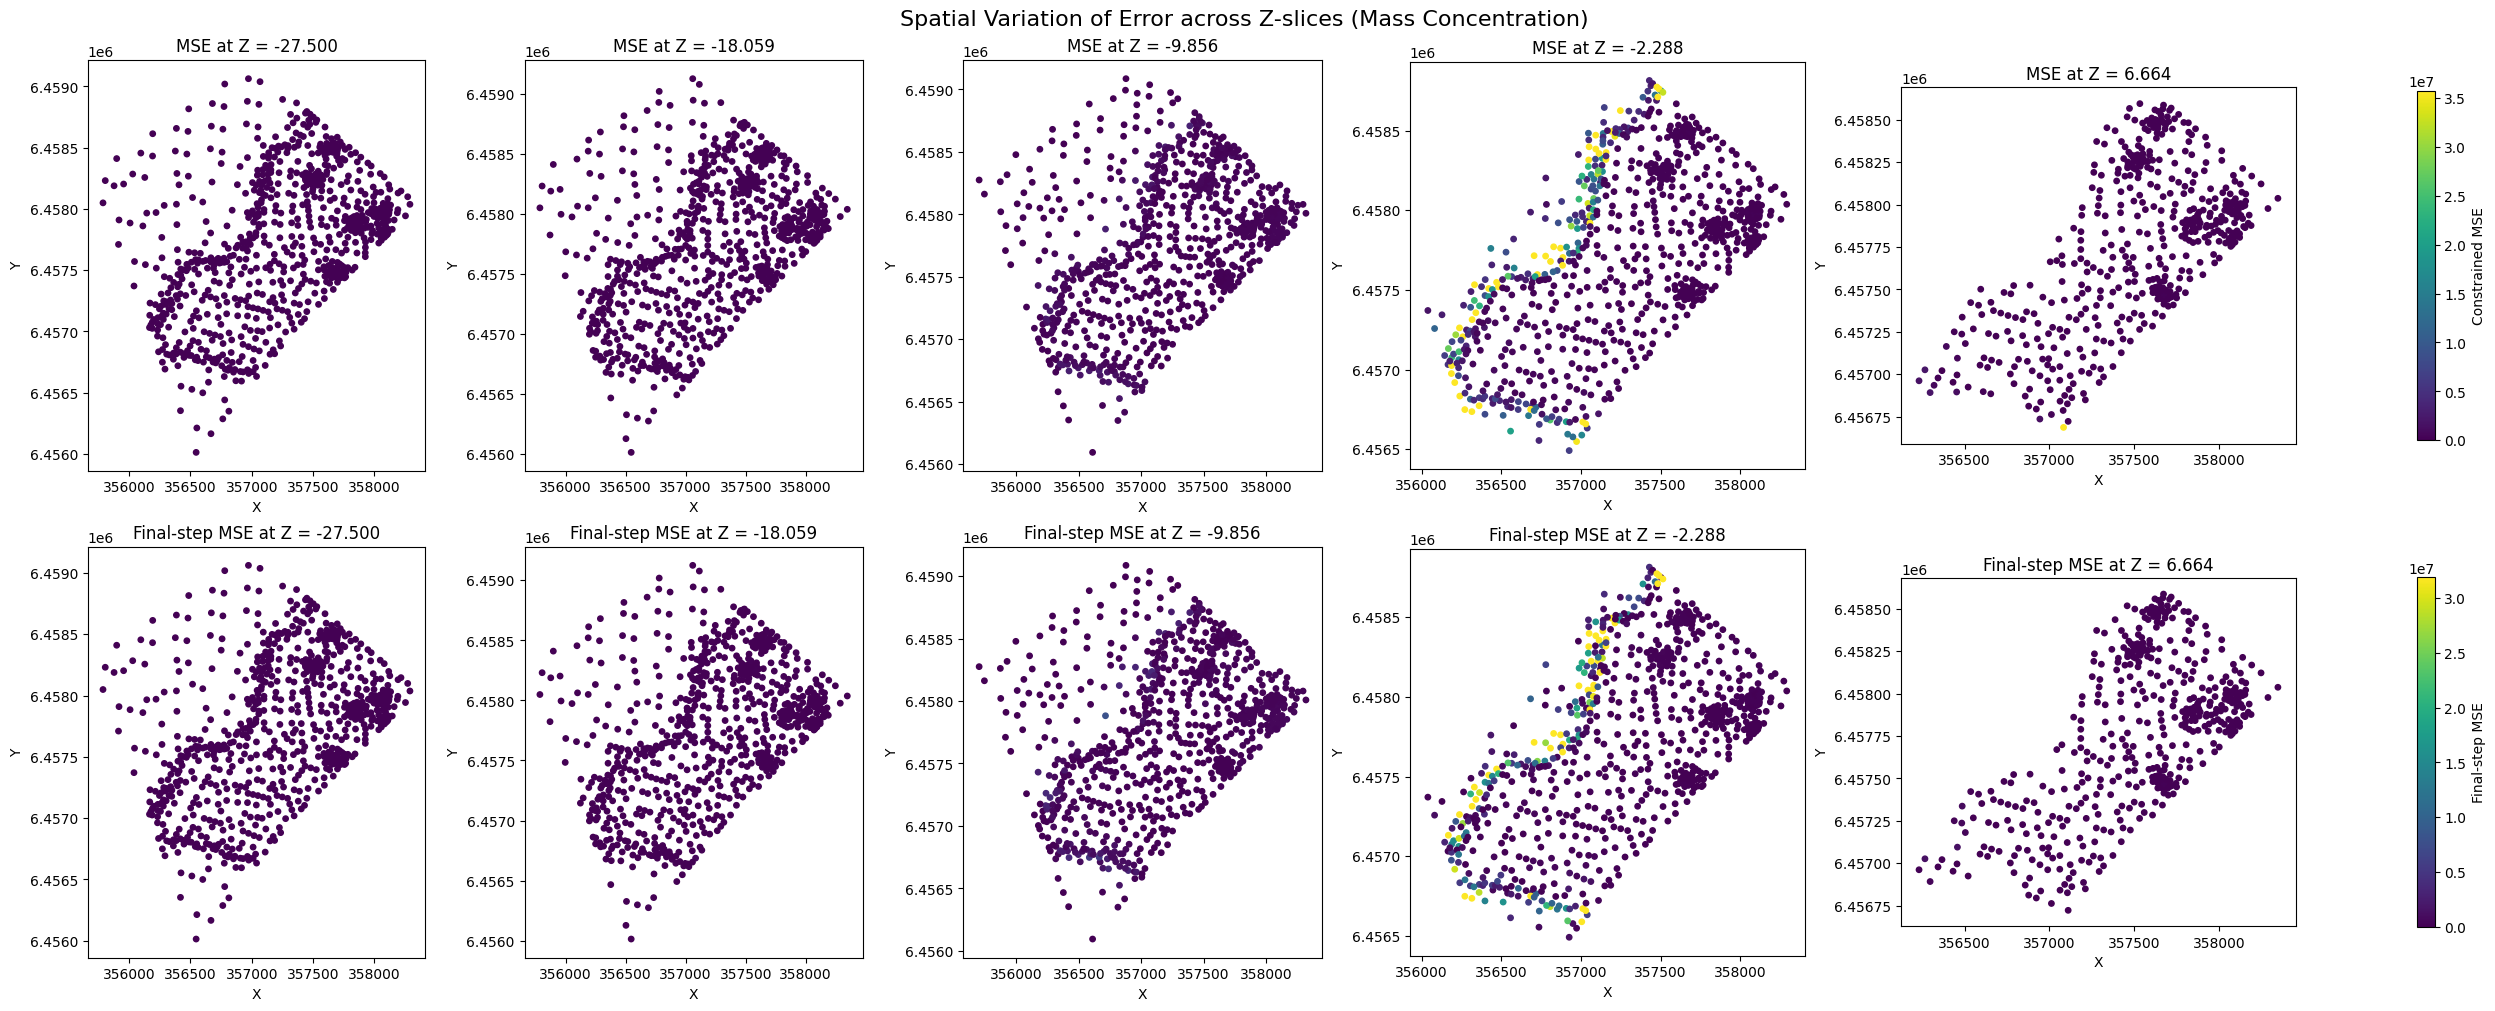

In [38]:
# Select Z levels to plot (e.g., bottom, middle, top)
z_values_to_plot = high_count_table.mean_z.values[1::2]
indices_to_plot = [np.argmin(np.abs(unique_z - z_val)) for z_val in z_values_to_plot]
print(f"Selected Z values for plotting: {unique_z[indices_to_plot]}")

n_cols = len(indices_to_plot)
# Use constrained_layout=True to automatically handle equal aspects and colorbar positioning without overlap
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10), squeeze=False, constrained_layout=True)

# Use percentile-based limits for better contrast
global_vmax_node = np.nanpercentile(node_mse, 98)
global_vmax_final = np.nanpercentile(final_mse, 98)

for i, z_idx in enumerate(indices_to_plot):
    z_val = unique_z[z_idx]
    mask = np.isclose(coords[:, 2], z_val, atol=0.6886512259462876)

    print(f"Plotting Z = {z_val:.3f} with {np.sum(mask)} nodes.")

    slice_coords = coords[mask]
    slice_node_mse = node_mse[mask]
    slice_final_mse = final_mse[mask]

    # Row 1: constrained MSE across time
    sc1 = axes[0, i].scatter(
        slice_coords[:, 0], slice_coords[:, 1],
        c=slice_node_mse, cmap='viridis', s=15, vmin=0, vmax=global_vmax_node
    )
    axes[0, i].set_title(f'MSE at Z = {z_val:.3f}')
    axes[0, i].set_xlabel('X')
    axes[0, i].set_ylabel('Y')
    axes[0, i].set_aspect('equal')

    # Row 2: final-step MSE
    sc2 = axes[1, i].scatter(
        slice_coords[:, 0], slice_coords[:, 1],
        c=slice_final_mse, cmap='viridis', s=15, vmin=0, vmax=global_vmax_final
    )
    axes[1, i].set_title(f'Final-step MSE at Z = {z_val:.3f}')
    axes[1, i].set_xlabel('X')
    axes[1, i].set_ylabel('Y')
    axes[1, i].set_aspect('equal')

# One colorbar per row assigned to the array of axes directly
cbar1 = fig.colorbar(sc1, ax=axes[0, :], label='Constrained MSE', shrink=0.85)
cbar2 = fig.colorbar(sc2, ax=axes[1, :], label='Final-step MSE', shrink=0.85)

plt.suptitle('Spatial Variation of Error across Z-slices (Mass Concentration)', fontsize=16)
# Removed plt.tight_layout() in favor of constrained_layout=True to prevent overlapping items
plt.show()

### Observation Analysis

From these plots, we can observe if the approximation error (MSE) is higher in the interior or near the boundaries.

- **Higher error in the interior**: Suggests the model might be struggling with the physics of transport or internal dynamics rather than just boundary effects.
- **Higher error near boundaries**: Points towards the irregular boundary conditions being the primary source of difficulty for the approximation.
- **Variation with Z**: If concentration is well-approximated near the surface but worsens at depth, it might indicate vertical stratification effects or specific boundary interactions at those depths.